# Enterprise AI-Powered Customer Analytics & Strategic Insight Framework

**SaaS / CRM Platform (Salesforce / Zoho style) — Capstone Notebook**

This notebook documents the analytical narrative behind the pipeline:

1. Data understanding and EDA over the star-schema CRM extract
2. Churn classification — ROC curve, confusion matrix, SHAP drivers
3. Revenue forecasting — residual and predicted-vs-actual diagnostics
4. Behavioural segmentation — elbow, silhouette and PCA cluster visualisation
5. Fused customer intelligence — risk vs revenue portfolio view

The production code lives in `src/` (`preprocessing.py`, `train_models.py`,
`fusion_layer.py`, `llm_insights.py`). This notebook consumes the artefacts
those modules produce.

## 1. Setup

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

PROJECT_DIR = Path(r"D:\DS_FO")
SOURCE_DIR = Path(r"D:\DS_F\DataSet-20260223T124234Z-1-001\DataSet")
PROCESSED_FILE = PROJECT_DIR / "data" / "processed" / "processed_customer_data.csv"
MODEL_DIR = PROJECT_DIR / "models"
REPORT_DIR = PROJECT_DIR / "reports"

RANDOM_STATE = 42
TEST_SIZE = 0.2

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.4.6


## 2. Data Understanding

The source is a star schema: four fact tables at different grains plus three
dimension tables. Everything is aggregated to **one row per customer** before
modelling.

In [2]:
raw_tables = {
    name: pd.read_csv(SOURCE_DIR / f"{name}.csv")
    for name in [
        "fact_customers",
        "fact_transactions",
        "fact_usage_monthly",
        "fact_engagement_events",
        "dim_geography",
        "dim_industry",
        "dim_product",
    ]
}

overview = pd.DataFrame(
    [
        {
            "table": name,
            "rows": len(df),
            "columns": df.shape[1],
            "unique_customers": (
                df["Customer_ID"].nunique() if "Customer_ID" in df else "-"
            ),
            "missing_cells": int(df.isna().sum().sum()),
        }
        for name, df in raw_tables.items()
    ]
)
overview

,table,rows,columns,unique_customers,missing_cells
0,fact_customers,5150,51,5000,2618
1,fact_transactions,54858,29,5000,30196
2,fact_usage_monthly,131268,22,5000,5270
3,fact_engagement_events,54822,19,5000,174206
4,dim_geography,183,12,-,21
5,dim_industry,22,8,-,0
6,dim_product,32,10,-,0


In [3]:
df = pd.read_csv(PROCESSED_FILE)
print("Processed modelling table:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate customer ids:", int(df["Customer_ID"].duplicated().sum()))
df[["Customer_ID", "Tenure_Months", "Health_Score", "ACV_USD", "Churn",
    "Next_Quarter_Revenue_USD"]].describe().round(2)

Processed modelling table: (5000, 190)
Missing values: 0
Duplicate customer ids: 0


,Customer_ID,Tenure_Months,Health_Score,ACV_USD,Churn,Next_Quarter_Revenue_USD
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,12500.50,35.10,63.59,20814.52,0.11,5541.66
std,1443.52,22.68,21.08,26537.24,0.32,7672.21
min,10001.00,3.00,0.00,0.00,0.00,0.00
25%,11250.75,17.00,48.00,1032.00,0.00,158.75
50%,12500.50,32.00,67.00,10137.50,0.00,1885.50
75%,13750.25,52.00,80.00,29911.50,0.00,8186.75
max,15000.00,108.00,100.00,155420.00,1.00,45455.00


### 2.1 Class imbalance

Churn is the classification target. The imbalance below is why SMOTE is applied
to the **training split only** — never to the hold-out set.

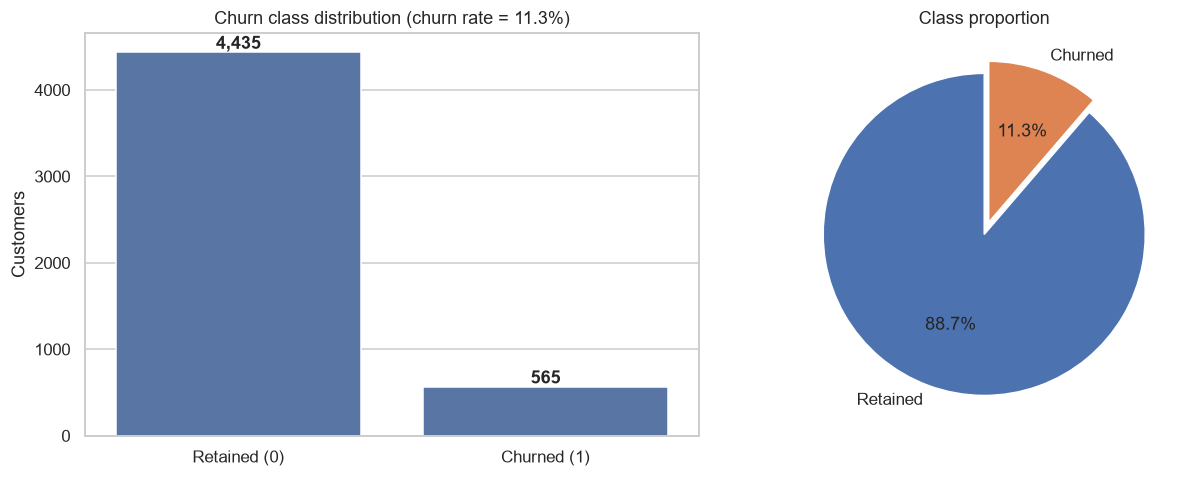

Imbalance ratio: 1 churner per 7.8 retained


In [4]:
churn_counts = df["Churn"].value_counts().sort_index()
churn_rate = df["Churn"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(x=["Retained (0)", "Churned (1)"], y=churn_counts.values, ax=axes[0])
axes[0].set_title(f"Churn class distribution (churn rate = {churn_rate:.1%})")
axes[0].set_ylabel("Customers")
for index, value in enumerate(churn_counts.values):
    axes[0].text(index, value + 40, f"{value:,}", ha="center", fontweight="bold")

axes[1].pie(
    churn_counts.values,
    labels=["Retained", "Churned"],
    autopct="%1.1f%%",
    startangle=90,
    explode=(0, 0.08),
)
axes[1].set_title("Class proportion")
plt.tight_layout()
plt.show()

print(f"Imbalance ratio: 1 churner per {churn_counts[0] / churn_counts[1]:.1f} retained")

### 2.2 Distribution of key business drivers

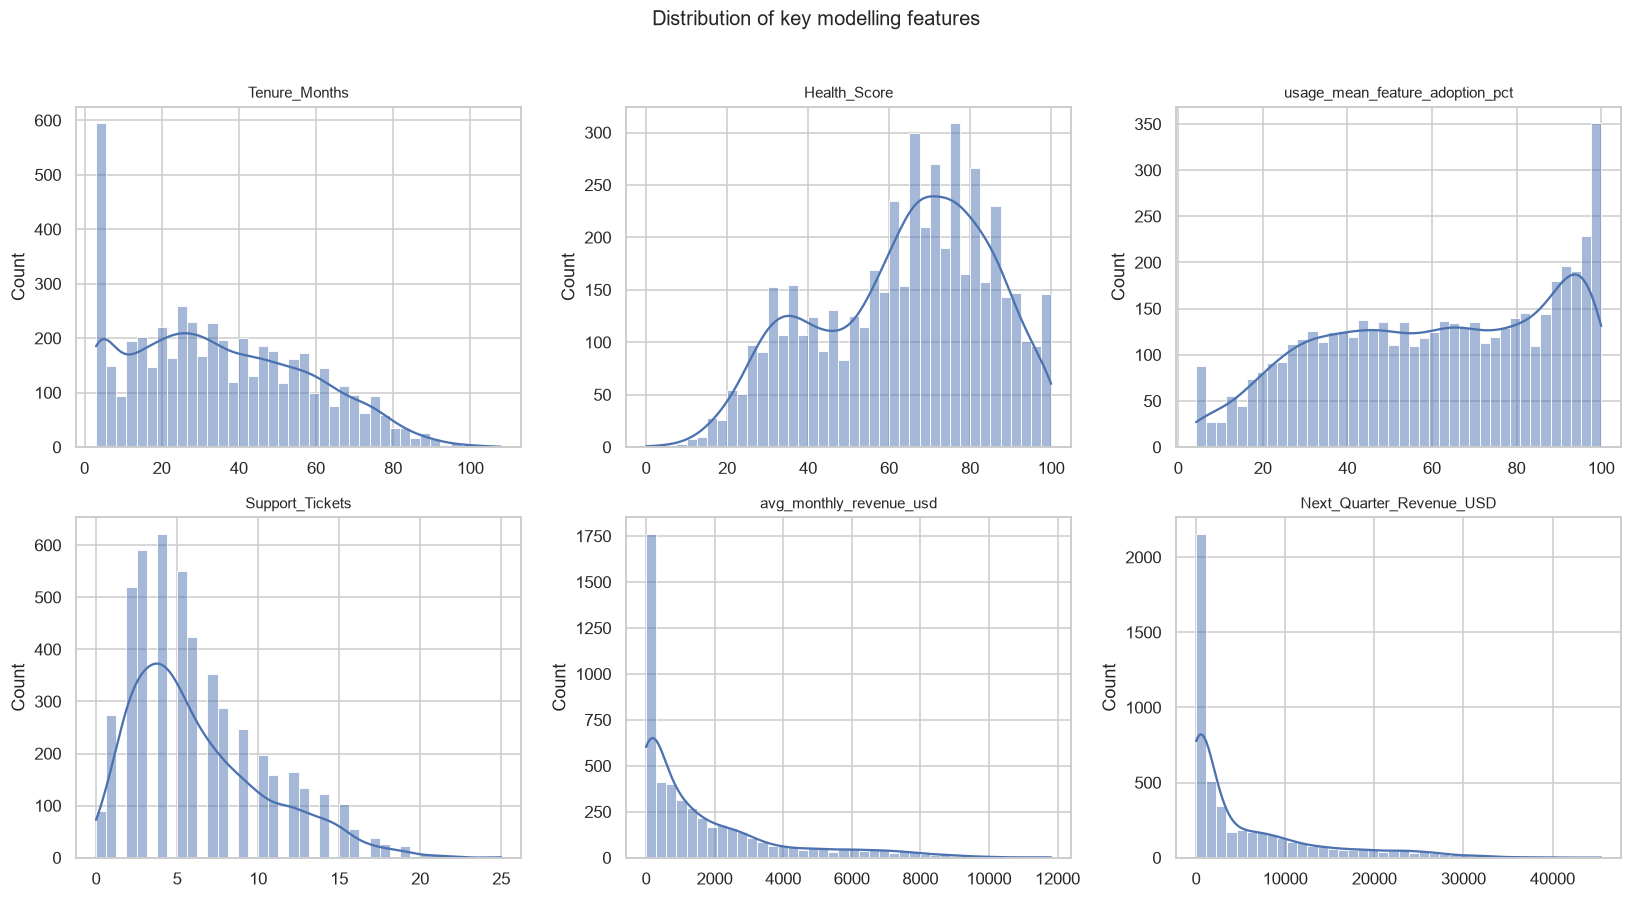

In [5]:
features_to_plot = [
    "Tenure_Months",
    "Health_Score",
    "usage_mean_feature_adoption_pct",
    "Support_Tickets",
    "avg_monthly_revenue_usd",
    "Next_Quarter_Revenue_USD",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, column in zip(axes.ravel(), features_to_plot):
    sns.histplot(df[column], bins=40, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(column, fontsize=10)
    ax.set_xlabel("")
fig.suptitle("Distribution of key modelling features", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Churned vs retained behaviour

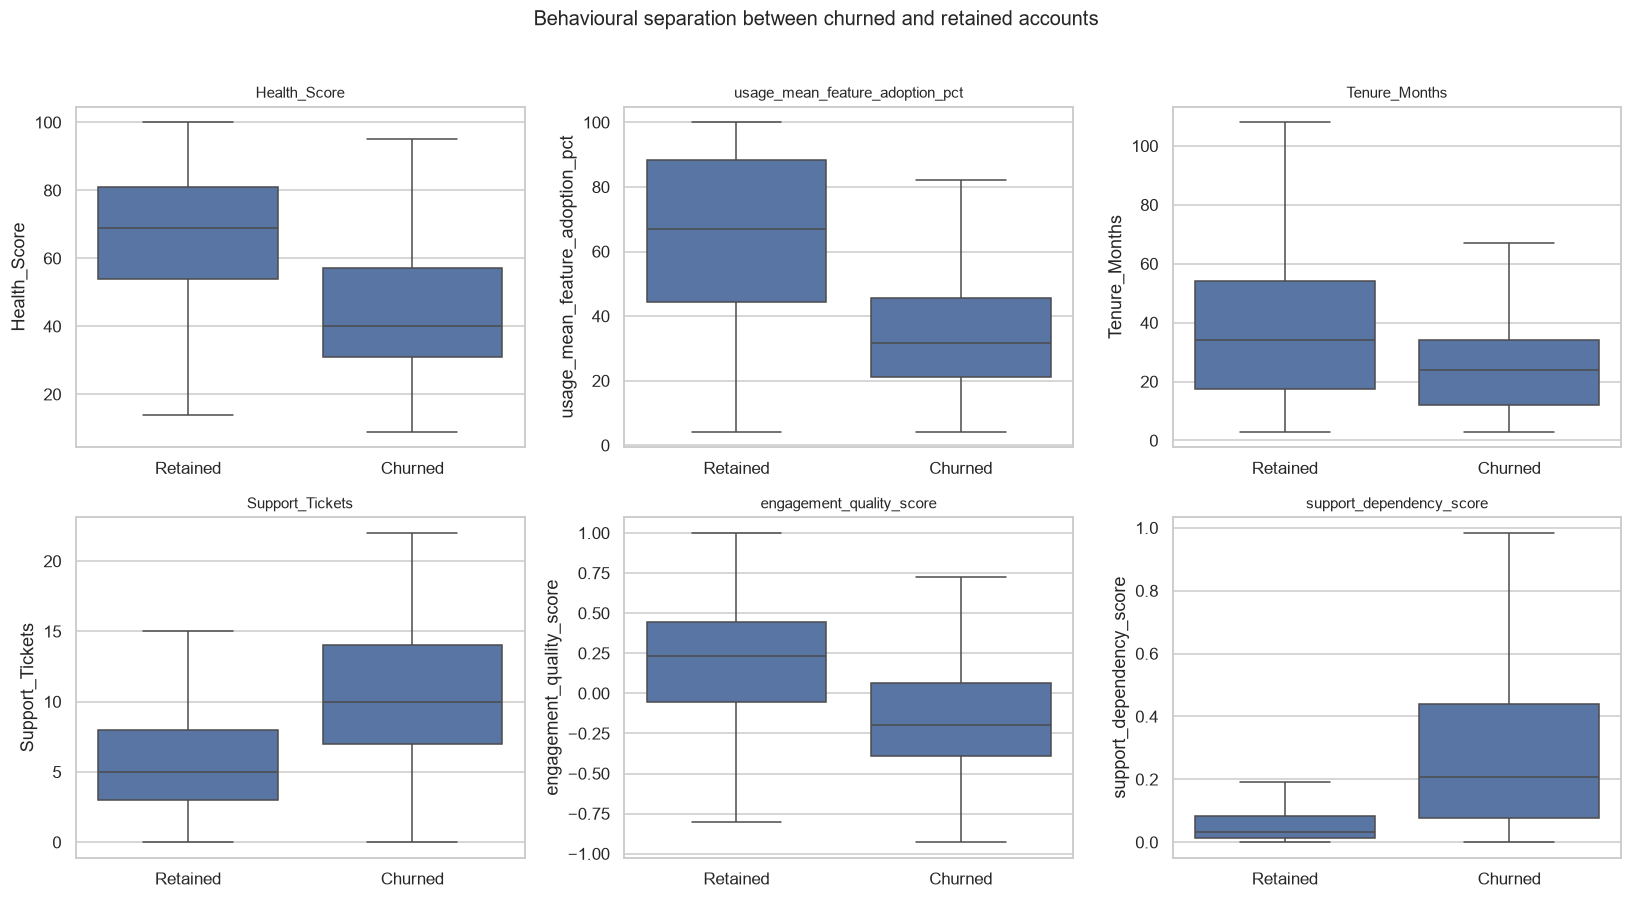

,Health_Score,usage_mean_feature_adoption_pct,Tenure_Months,Support_Tickets,engagement_quality_score,support_dependency_score
Churn,,,,,,
0,66.01,64.49,36.38,5.78,0.18,0.29
1,44.56,35.83,25.09,10.25,-0.14,1.01


In [6]:
comparison_features = [
    "Health_Score",
    "usage_mean_feature_adoption_pct",
    "Tenure_Months",
    "Support_Tickets",
    "engagement_quality_score",
    "support_dependency_score",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, column in zip(axes.ravel(), comparison_features):
    sns.boxplot(data=df, x="Churn", y=column, ax=ax, showfliers=False)
    ax.set_title(column, fontsize=10)
    ax.set_xticklabels(["Retained", "Churned"])
    ax.set_xlabel("")
fig.suptitle("Behavioural separation between churned and retained accounts",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

df.groupby("Churn")[comparison_features].mean().round(2)

### 2.4 Correlation structure

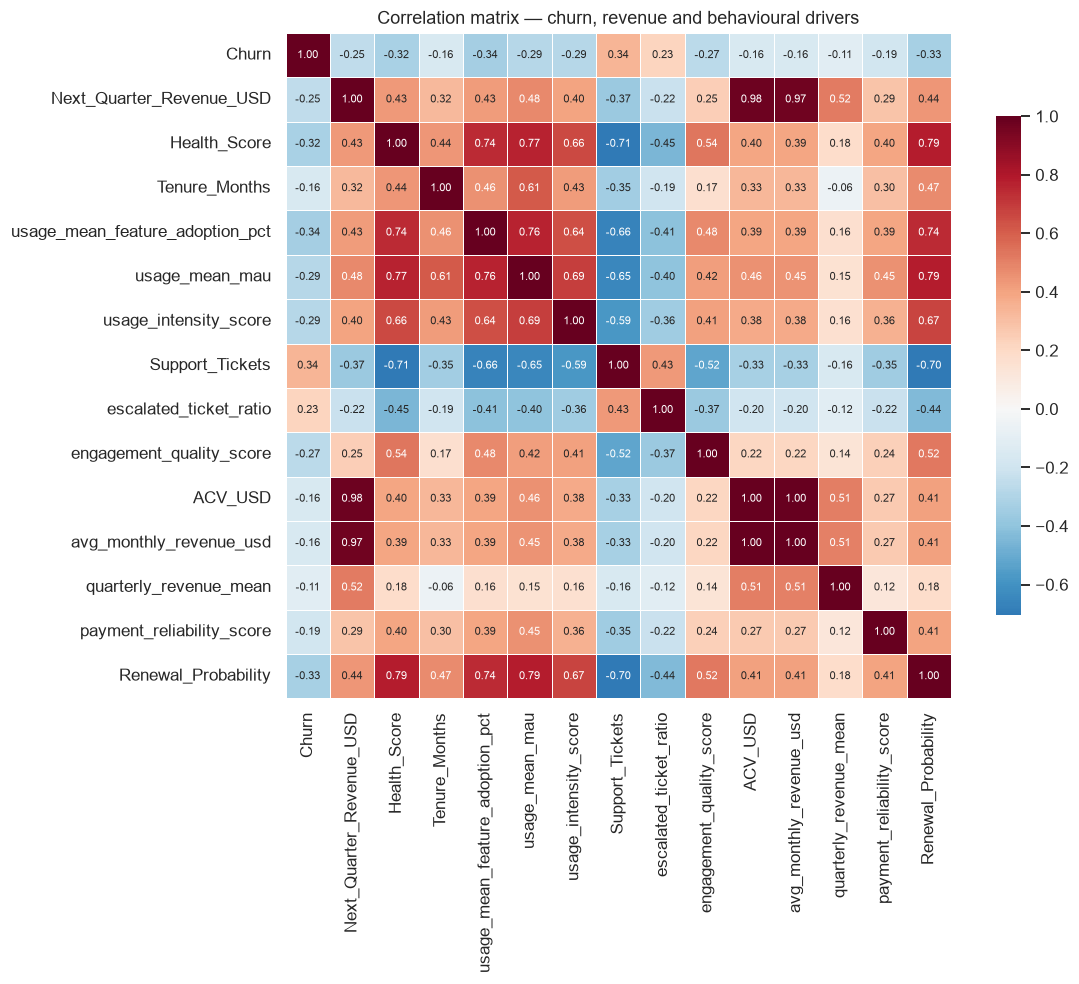

In [7]:
correlation_features = [
    "Churn", "Next_Quarter_Revenue_USD", "Health_Score", "Tenure_Months",
    "usage_mean_feature_adoption_pct", "usage_mean_mau", "usage_intensity_score",
    "Support_Tickets", "escalated_ticket_ratio", "engagement_quality_score",
    "ACV_USD", "avg_monthly_revenue_usd", "quarterly_revenue_mean",
    "payment_reliability_score", "Renewal_Probability",
]

correlation = df[correlation_features].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.75},
)
plt.title("Correlation matrix — churn, revenue and behavioural drivers")
plt.tight_layout()
plt.show()

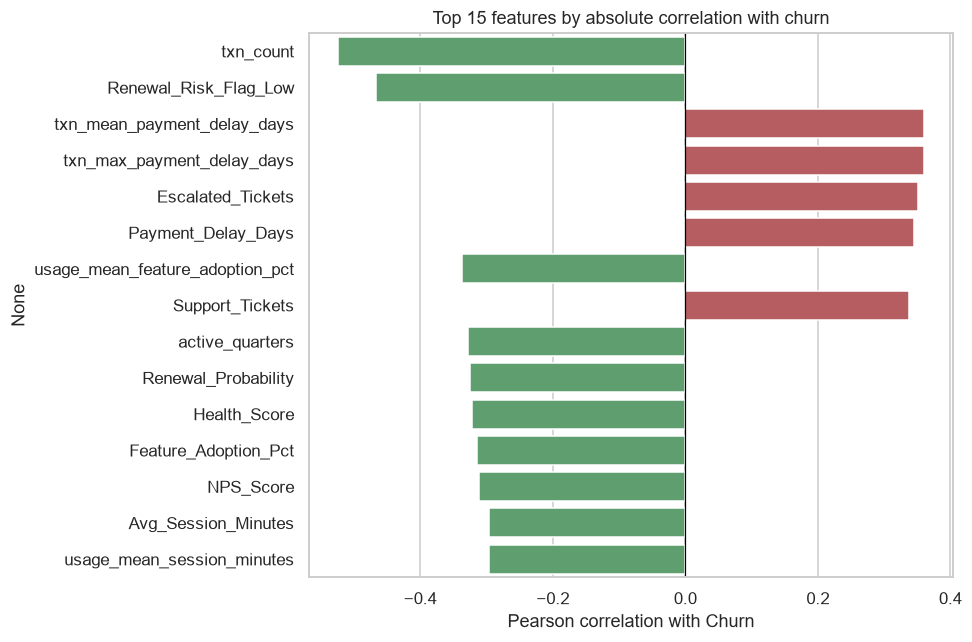

In [8]:
churn_correlation = (
    df.corr(numeric_only=True)["Churn"]
    .drop(["Churn", "Customer_ID"])
    .sort_values(key=abs, ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))
colors = ["#C44E52" if v > 0 else "#55A868" for v in churn_correlation.values]
sns.barplot(x=churn_correlation.values, y=churn_correlation.index, palette=colors)
plt.title("Top 15 features by absolute correlation with churn")
plt.xlabel("Pearson correlation with Churn")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### 2.5 Revenue trend across fiscal quarters

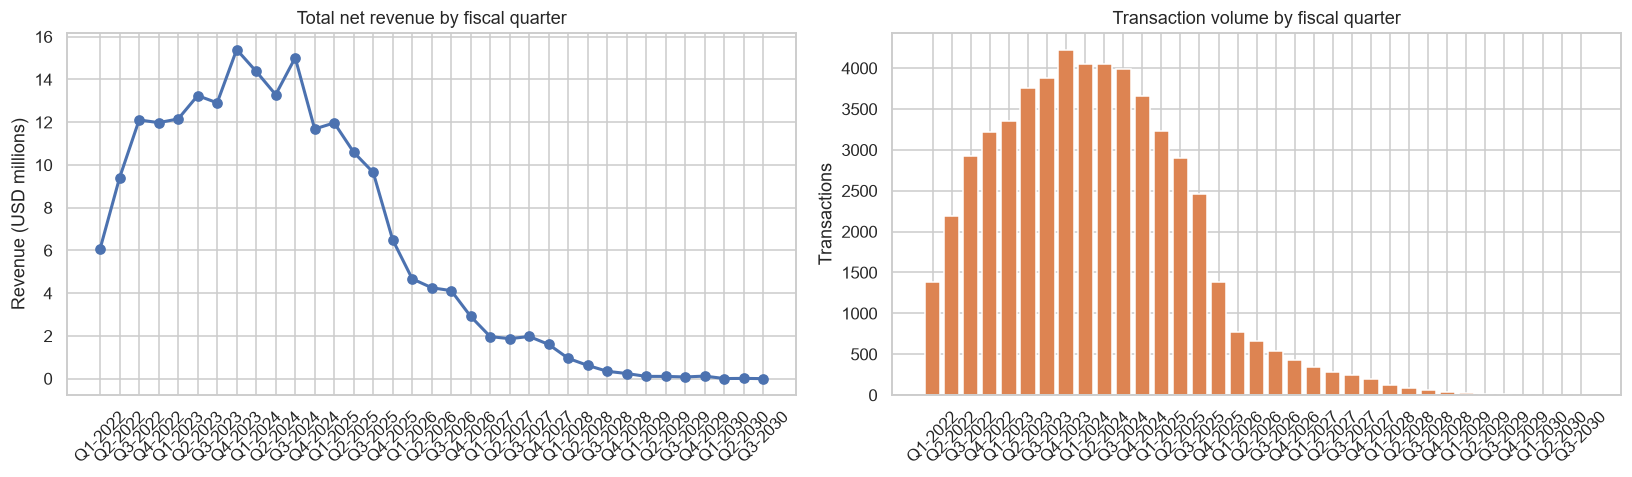

In [9]:
transactions = raw_tables["fact_transactions"].drop_duplicates()
transactions["quarter_key"] = (
    transactions["Fiscal_Quarter"].str.slice(3).astype(int) * 10
    + transactions["Fiscal_Quarter"].str.slice(1, 2).astype(int)
)
quarterly = (
    transactions.groupby(["quarter_key", "Fiscal_Quarter"])["Net_Revenue_USD"]
    .agg(["sum", "mean", "count"])
    .reset_index()
    .sort_values("quarter_key")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].plot(quarterly["Fiscal_Quarter"], quarterly["sum"] / 1e6,
             marker="o", linewidth=2, color="#4C72B0")
axes[0].set_title("Total net revenue by fiscal quarter")
axes[0].set_ylabel("Revenue (USD millions)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(quarterly["Fiscal_Quarter"], quarterly["count"], color="#DD8452")
axes[1].set_title("Transaction volume by fiscal quarter")
axes[1].set_ylabel("Transactions")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 3. Model 1 — Churn Classification

The serialised classifier is reloaded and evaluated on the same stratified
hold-out split used during training (`random_state=42`), so the numbers here
reproduce `reports/model_metrics.json`.

In [10]:
classifier = joblib.load(MODEL_DIR / "classifier.pkl")
regressor = joblib.load(MODEL_DIR / "regressor.pkl")
clusterer = joblib.load(MODEL_DIR / "clusterer.pkl")
scaler = joblib.load(MODEL_DIR / "scaler.pkl")
pca = joblib.load(MODEL_DIR / "segmentation_pca.pkl")
contract = joblib.load(MODEL_DIR / "feature_contract.pkl")

metrics = json.loads((REPORT_DIR / "model_metrics.json").read_text())

churn_features = df[contract["churn_features"]]
churn_target = df["Churn"]
x_train, x_test, y_train, y_test = train_test_split(
    churn_features, churn_target, test_size=TEST_SIZE,
    stratify=churn_target, random_state=RANDOM_STATE,
)

probabilities = classifier.predict_proba(x_test)[:, 1]
predictions = classifier.predict(x_test)
print(f"Hold-out ROC-AUC : {roc_auc_score(y_test, probabilities):.4f}")
print(f"Hold-out F1      : {metrics['churn_classification']['f1_score']:.4f}")

Hold-out ROC-AUC : 0.9113
Hold-out F1      : 0.6146


### 3.1 ROC curve and confusion matrix

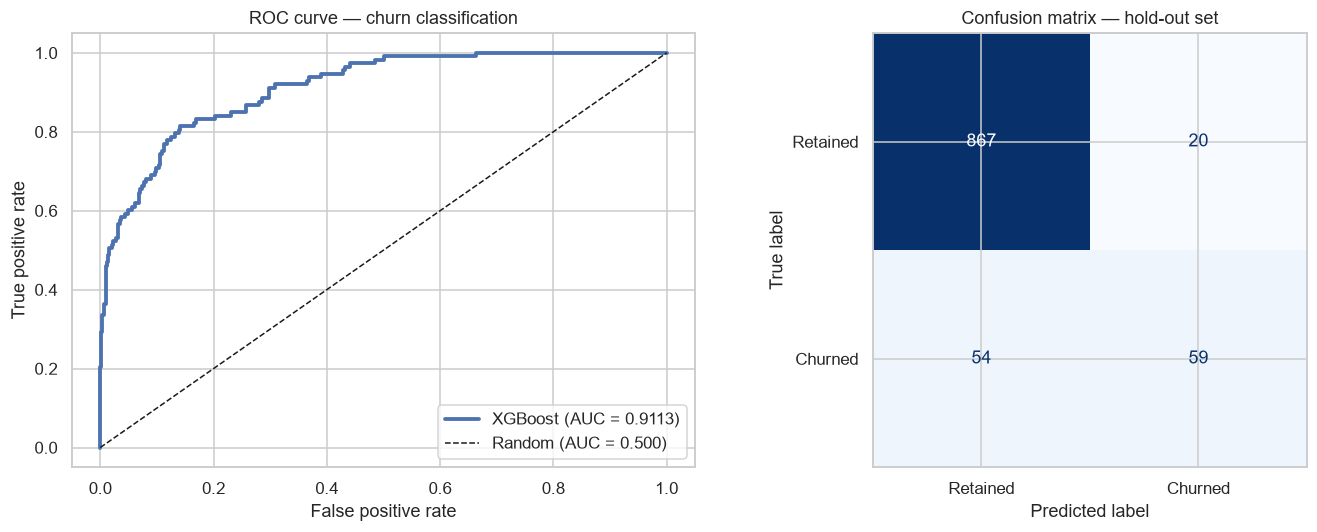

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

false_positive, true_positive, _ = roc_curve(y_test, probabilities)
auc = roc_auc_score(y_test, probabilities)
axes[0].plot(false_positive, true_positive, linewidth=2.5,
             label=f"XGBoost (AUC = {auc:.4f})", color="#4C72B0")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.500)")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve — churn classification")
axes[0].legend(loc="lower right")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, predictions),
    display_labels=["Retained", "Churned"],
).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Confusion matrix — hold-out set")
plt.tight_layout()
plt.show()

### 3.2 SHAP — explainable churn drivers

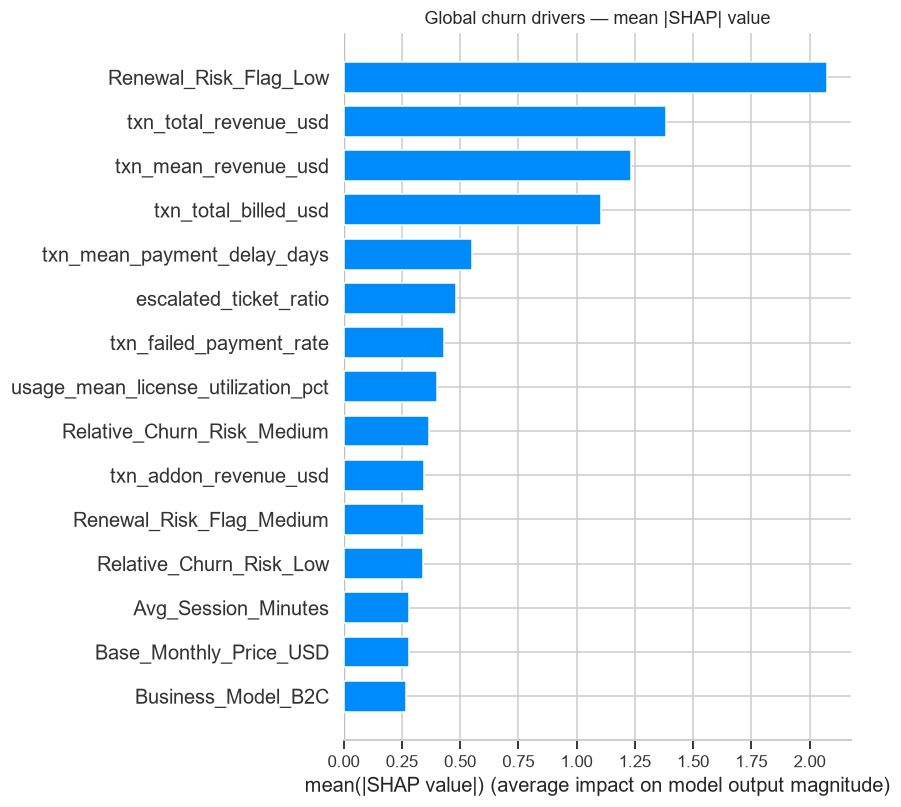

In [12]:
shap_sample = x_test.sample(n=min(500, len(x_test)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample, plot_type="bar",
                  max_display=15, show=False)
plt.title("Global churn drivers — mean |SHAP| value")
plt.tight_layout()
plt.show()

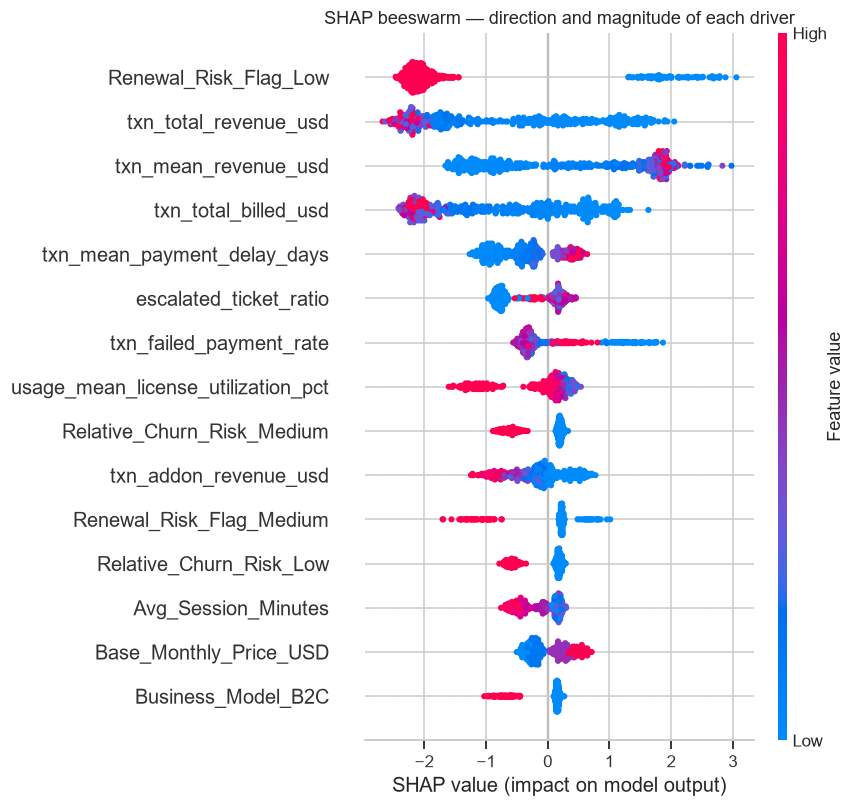

In [13]:
shap.summary_plot(shap_values, shap_sample, max_display=15, show=False)
plt.title("SHAP beeswarm — direction and magnitude of each driver")
plt.tight_layout()
plt.show()

**Reading the beeswarm:** red points are high feature values, blue are low.
Points to the right push the prediction toward churn.

### 3.3 Target-leakage handling

Four record-count features were found to encode the churn outcome rather than
predict it — they fall simply because a churned customer **stops generating
rows**. All four correlate negatively with churn. They are withheld from the
shipped model:

`txn_count` · `txn_renewal_count` · `active_quarters` · `usage_months_observed`

Engagement counts are deliberately **kept**: they correlate *positively* with
churn (+0.27), because distressed customers raise *more* tickets. That is
genuine leading signal, not a temporal artefact. The cost of the exclusion was
measured rather than assumed.

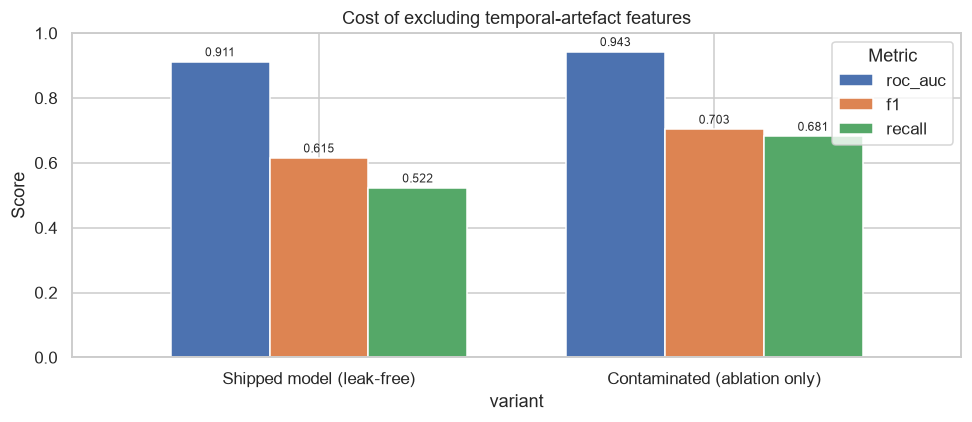

Cost of removing leakage: +0.0313 ROC-AUC, +0.1593 recall


,features,roc_auc,f1,recall
variant,,,,
Shipped model (leak-free),180,0.9113,0.6146,0.5221
Contaminated (ablation only),184,0.9425,0.7032,0.6814


In [14]:
ablation = metrics["churn_classification"]["leakage_ablation"]
churn_metrics = metrics["churn_classification"]

comparison = pd.DataFrame([
    {
        "variant": "Shipped model (leak-free)",
        "features": churn_metrics["n_features"],
        "roc_auc": churn_metrics["roc_auc"],
        "f1": churn_metrics["f1_score"],
        "recall": churn_metrics["recall"],
    },
    {
        "variant": "Contaminated (ablation only)",
        "features": ablation["n_features"],
        "roc_auc": ablation["roc_auc"],
        "f1": ablation["f1_score"],
        "recall": ablation["recall"],
    },
]).set_index("variant")

fig, ax = plt.subplots(figsize=(9, 4))
comparison[["roc_auc", "f1", "recall"]].plot(kind="bar", ax=ax, rot=0, width=0.75)
ax.set_title("Cost of excluding temporal-artefact features")
ax.set_ylabel("Score"); ax.set_ylim(0, 1.0)
ax.legend(title="Metric")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()

print(f"Cost of removing leakage: {ablation['roc_auc'] - churn_metrics['roc_auc']:+.4f} "
      f"ROC-AUC, {ablation['recall'] - churn_metrics['recall']:+.4f} recall")
comparison.round(4)

The contaminated variant scores roughly 0.043 higher ROC-AUC partly by
reading the outcome it is meant to forecast. The lower figure is the honest one.

**Cross-validation note.** The `cv_roc_auc_mean` below is computed with SMOTE
refitted *inside* each fold via an `imblearn` pipeline. Cross-validating a model
already fitted on pre-balanced data reported 0.9954 — optimistic, because
synthetic rows derived from a validation record reach the training folds.

In [15]:
print(f"Honest CV ROC-AUC : {churn_metrics['cv_roc_auc_mean']:.4f} "
      f"(+/- {churn_metrics['cv_roc_auc_std']:.4f})")
print(f"Method            : {churn_metrics['cv_method']}")
print(f"Hold-out ROC-AUC  : {churn_metrics['roc_auc']:.4f}")
print(f"Precision / Recall: {churn_metrics['precision']:.3f} / {churn_metrics['recall']:.3f}")

Honest CV ROC-AUC : 0.9080 (+/- 0.0103)
Method            : SMOTE inside imblearn Pipeline, refitted per fold
Hold-out ROC-AUC  : 0.9113
Precision / Recall: 0.747 / 0.522


## 4. Model 2 — Revenue Forecasting

Target: `Next_Quarter_Revenue_USD`. GradientBoosting was selected over XGBoost
on hold-out RMSE.

In [16]:
revenue_features = df[contract["revenue_features"]]
revenue_target = df["Next_Quarter_Revenue_USD"]
xr_train, xr_test, yr_train, yr_test = train_test_split(
    revenue_features, revenue_target, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

revenue_predictions = regressor.predict(xr_test)
residuals = yr_test - revenue_predictions

regression_metrics = metrics["revenue_regression"]
print(f"Selected model : {regression_metrics['selected_model']}")
print(f"RMSE           : {regression_metrics['rmse']:,.2f}")
print(f"MAE            : {regression_metrics['mae']:,.2f}")
print(f"R2             : {regression_metrics['r2']:.4f}")
print(f"Adjusted R2    : {regression_metrics['adjusted_r2']:.4f}")

Selected model : gradient_boosting
RMSE           : 1,363.28
MAE            : 692.37
R2             : 0.9674
Adjusted R2    : 0.9600


### 4.1 Predicted vs actual, residual diagnostics

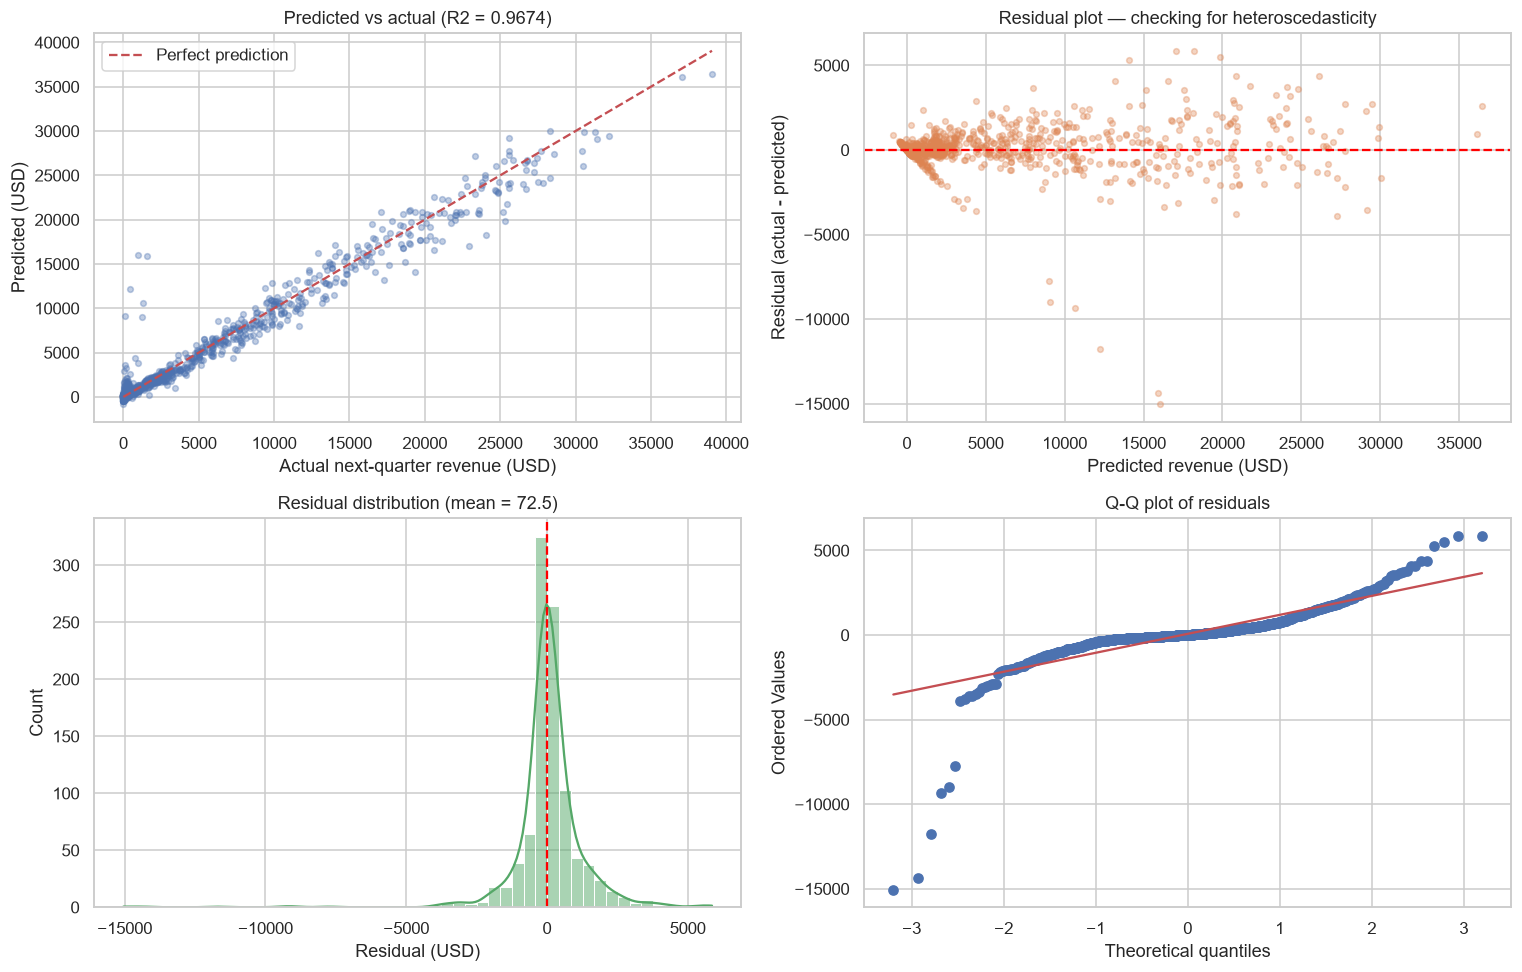

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].scatter(yr_test, revenue_predictions, alpha=0.35, s=14, color="#4C72B0")
limits = [0, max(yr_test.max(), revenue_predictions.max())]
axes[0, 0].plot(limits, limits, "r--", linewidth=1.5, label="Perfect prediction")
axes[0, 0].set_xlabel("Actual next-quarter revenue (USD)")
axes[0, 0].set_ylabel("Predicted (USD)")
axes[0, 0].set_title(f"Predicted vs actual (R2 = {regression_metrics['r2']:.4f})")
axes[0, 0].legend()

axes[0, 1].scatter(revenue_predictions, residuals, alpha=0.35, s=14, color="#DD8452")
axes[0, 1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[0, 1].set_xlabel("Predicted revenue (USD)")
axes[0, 1].set_ylabel("Residual (actual - predicted)")
axes[0, 1].set_title("Residual plot — checking for heteroscedasticity")

sns.histplot(residuals, bins=50, kde=True, ax=axes[1, 0], color="#55A868")
axes[1, 0].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1, 0].set_title(f"Residual distribution (mean = {residuals.mean():,.1f})")
axes[1, 0].set_xlabel("Residual (USD)")

from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q plot of residuals")

plt.tight_layout()
plt.show()

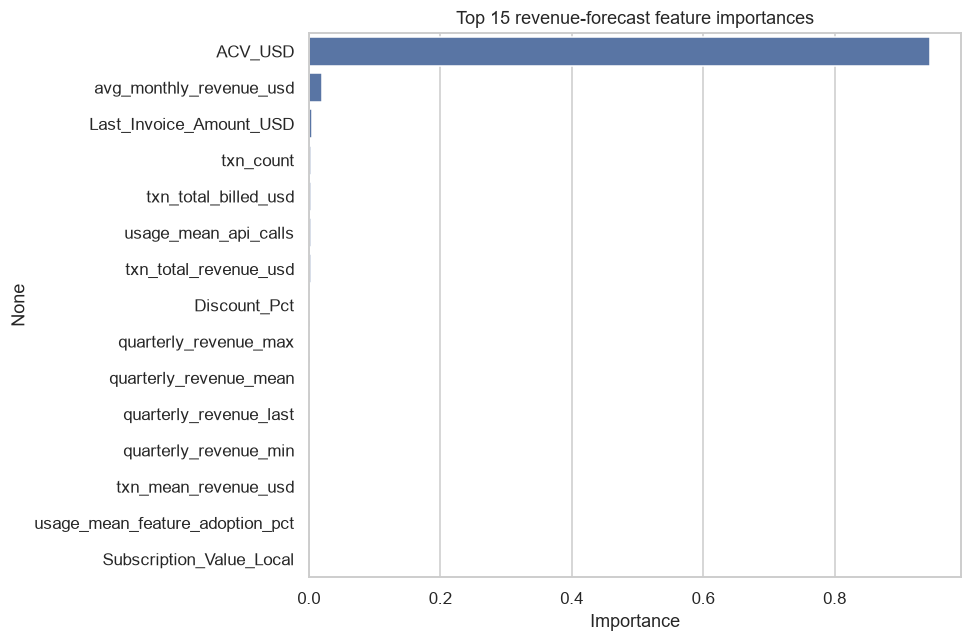

In [18]:
importance = pd.Series(
    regressor.feature_importances_, index=revenue_features.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=importance.values, y=importance.index, color="#4C72B0")
plt.title("Top 15 revenue-forecast feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 5. Model 3 — Behavioural Segmentation

Behavioural features are log-compressed, standardised, reduced with PCA
(90% variance retained), then clustered with KMeans.

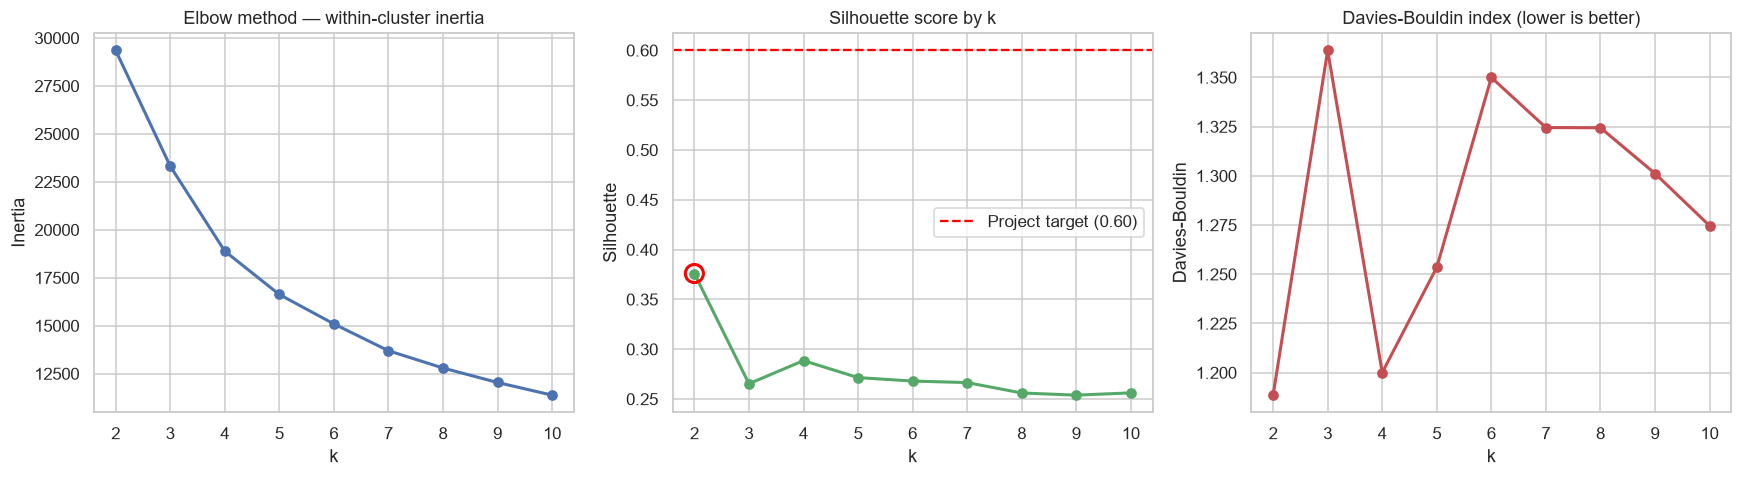

,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,2,0.3760,1.1886,2723.3710,29355.4063
1,3,0.2654,1.3638,2360.6056,23318.8887
2,4,0.2885,1.2000,2333.4565,18886.7557
3,5,0.2715,1.2535,2157.6109,16625.3352
4,6,0.2680,1.3500,2002.6391,15091.5473
5,7,0.2665,1.3245,1924.0684,13692.6348
6,8,0.2560,1.3244,1815.2752,12791.2516
7,9,0.2539,1.3012,1726.6304,12037.0786
8,10,0.2562,1.2747,1655.7348,11376.6740


In [19]:
sweep = pd.read_csv(REPORT_DIR / "clustering_sweep.csv")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(sweep["k"], sweep["inertia"], marker="o", linewidth=2, color="#4C72B0")
axes[0].set_title("Elbow method — within-cluster inertia")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(sweep["k"], sweep["silhouette"], marker="o", linewidth=2, color="#55A868")
axes[1].axhline(0.60, color="red", linestyle="--", label="Project target (0.60)")
best_row = sweep.loc[sweep["silhouette"].idxmax()]
axes[1].scatter([best_row["k"]], [best_row["silhouette"]], s=140,
                facecolors="none", edgecolors="red", linewidths=2, zorder=5)
axes[1].set_title("Silhouette score by k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
axes[1].legend()

axes[2].plot(sweep["k"], sweep["davies_bouldin"], marker="o",
             linewidth=2, color="#C44E52")
axes[2].set_title("Davies-Bouldin index (lower is better)")
axes[2].set_xlabel("k"); axes[2].set_ylabel("Davies-Bouldin")
plt.tight_layout()
plt.show()

sweep.round(4)

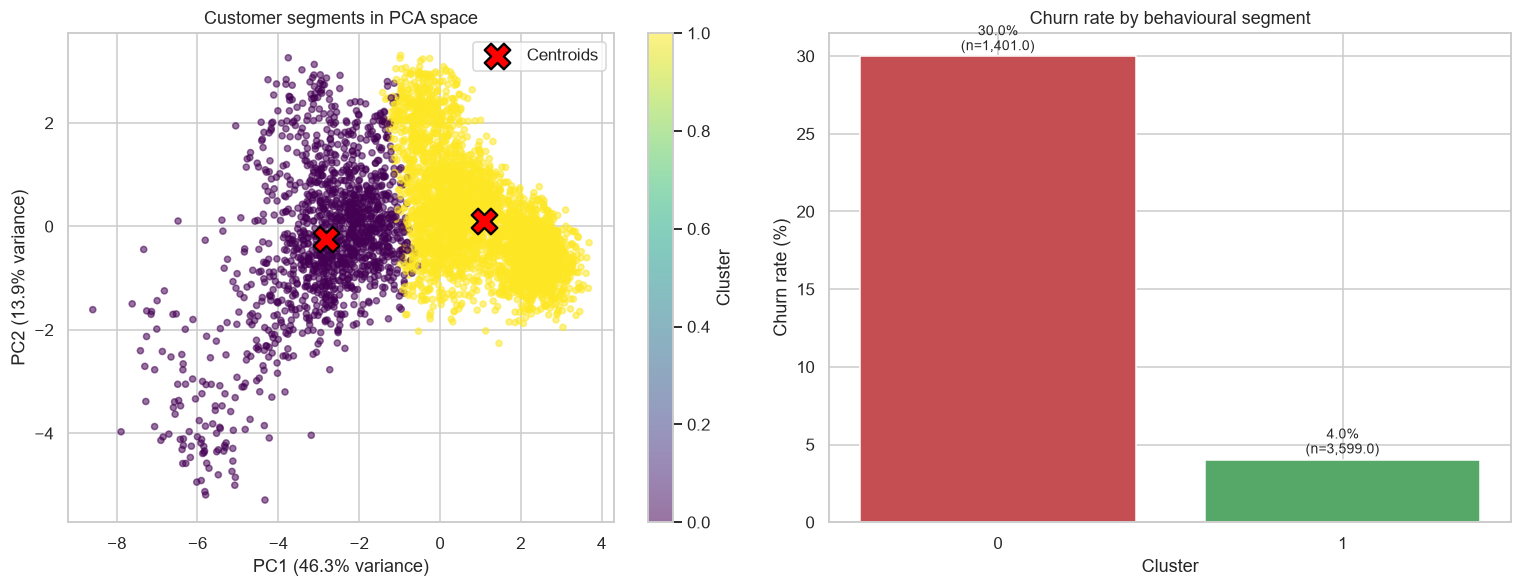

In [20]:
segment_data = df[contract["segmentation_features"]].copy()
for column in contract["log_scale_features"]:
    segment_data[column] = np.log1p(segment_data[column].clip(lower=0))

scaled = scaler.transform(segment_data)
reduced = pca.transform(scaled)
labels = clusterer.predict(reduced)
df["cluster_id"] = labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
scatter = axes[0].scatter(reduced[:, 0], reduced[:, 1], c=labels,
                          cmap="viridis", alpha=0.55, s=16)
centroids = clusterer.cluster_centers_
axes[0].scatter(centroids[:, 0], centroids[:, 1], marker="X", s=280,
                c="red", edgecolors="black", linewidths=1.5, label="Centroids")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
axes[0].set_title("Customer segments in PCA space")
axes[0].legend()
plt.colorbar(scatter, ax=axes[0], label="Cluster")

cluster_churn = df.groupby("cluster_id")["Churn"].agg(["mean", "size"])
bars = axes[1].bar(cluster_churn.index.astype(str),
                   cluster_churn["mean"] * 100, color=["#C44E52", "#55A868"])
axes[1].set_title("Churn rate by behavioural segment")
axes[1].set_xlabel("Cluster"); axes[1].set_ylabel("Churn rate (%)")
for bar, (_, row) in zip(bars, cluster_churn.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                 f"{bar.get_height():.1f}%\n(n={row['size']:,})",
                 ha="center", fontsize=9)
plt.tight_layout()
plt.show()

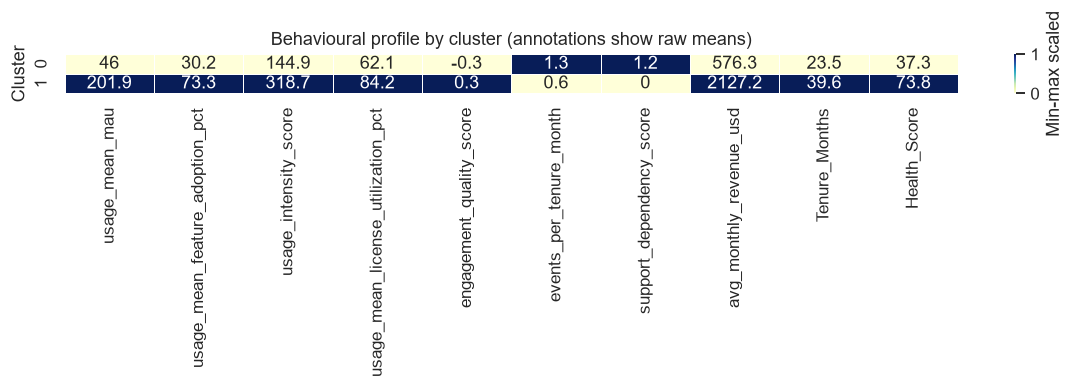

,usage_mean_mau,usage_mean_feature_adoption_pct,usage_intensity_score,usage_mean_license_utilization_pct,engagement_quality_score,events_per_tenure_month,support_dependency_score,avg_monthly_revenue_usd,Tenure_Months,Health_Score,churn_rate
cluster,,,,,,,,,,,
0,46.02,30.20,144.91,62.12,-0.26,1.3,1.24,576.29,23.50,37.26,0.30
1,201.90,73.34,318.72,84.15,0.30,0.6,0.03,2127.22,39.62,73.83,0.04


In [21]:
cluster_profile = pd.read_csv(REPORT_DIR / "cluster_profiles.csv", index_col=0)

normalised = cluster_profile.drop(columns=["churn_rate"])
normalised = (normalised - normalised.min()) / (normalised.max() - normalised.min())

plt.figure(figsize=(11, 3.5))
sns.heatmap(normalised, annot=cluster_profile.drop(columns=["churn_rate"]).round(1),
            fmt="g", cmap="YlGnBu", linewidths=0.5, cbar_kws={"label": "Min-max scaled"})
plt.title("Behavioural profile by cluster (annotations show raw means)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

cluster_profile.round(2)

**Segmentation verdict.** The best silhouette is **0.376 at k=2**, below the
0.60 project target. This is an honest result, not a tuning failure: SaaS
behavioural features are continuous and overlapping, so customers form a
gradient rather than well-separated spheres. The two segments are nonetheless
commercially sharp — a 7.5x churn-rate gap — which is what the business
actually needs from segmentation.

## 6. Fused Customer Intelligence

`fusion_layer.py` combines all three model outputs into one profile per
customer. The portfolio view below is what drives account prioritisation.

In [22]:
fusion = pd.read_csv(REPORT_DIR / "fusion_summary.csv")
print("Fused profiles:", fusion.shape)
print("\nRisk distribution:")
print(fusion["risk_level"].value_counts())
print(f"\nTotal forecast revenue at risk: ${fusion['revenue_at_risk_usd'].sum():,.0f}")
fusion.head()

Fused profiles: (5000, 11)

Risk distribution:
risk_level
Low       4445
High       521
Medium      34
Name: count, dtype: int64

Total forecast revenue at risk: $624,460


,Customer_ID,churn_probability,risk_level,predicted_next_quarter_revenue_usd,revenue_at_risk_usd,cluster_id,cluster_label,engagement_level,risk_score,revenue_potential_score,priority_score
0,11177,0.007790,Low,87.700488,0.683225,0,Disengaged At-Risk Accounts,Low,75.8,9.8,37.3
1,14771,0.000963,Low,12115.765593,11.670466,0,Disengaged At-Risk Accounts,Moderate,47.4,83.1,77.6
2,11091,0.000033,Low,19268.313067,0.642069,1,Loyal High-Value Accounts,High,5.3,91.4,36.0
3,14818,0.998980,High,584.926909,584.330206,0,Disengaged At-Risk Accounts,Low,99.5,33.7,95.1
4,14376,0.001287,Low,3132.434497,4.031548,1,Loyal High-Value Accounts,High,52.0,60.1,65.5


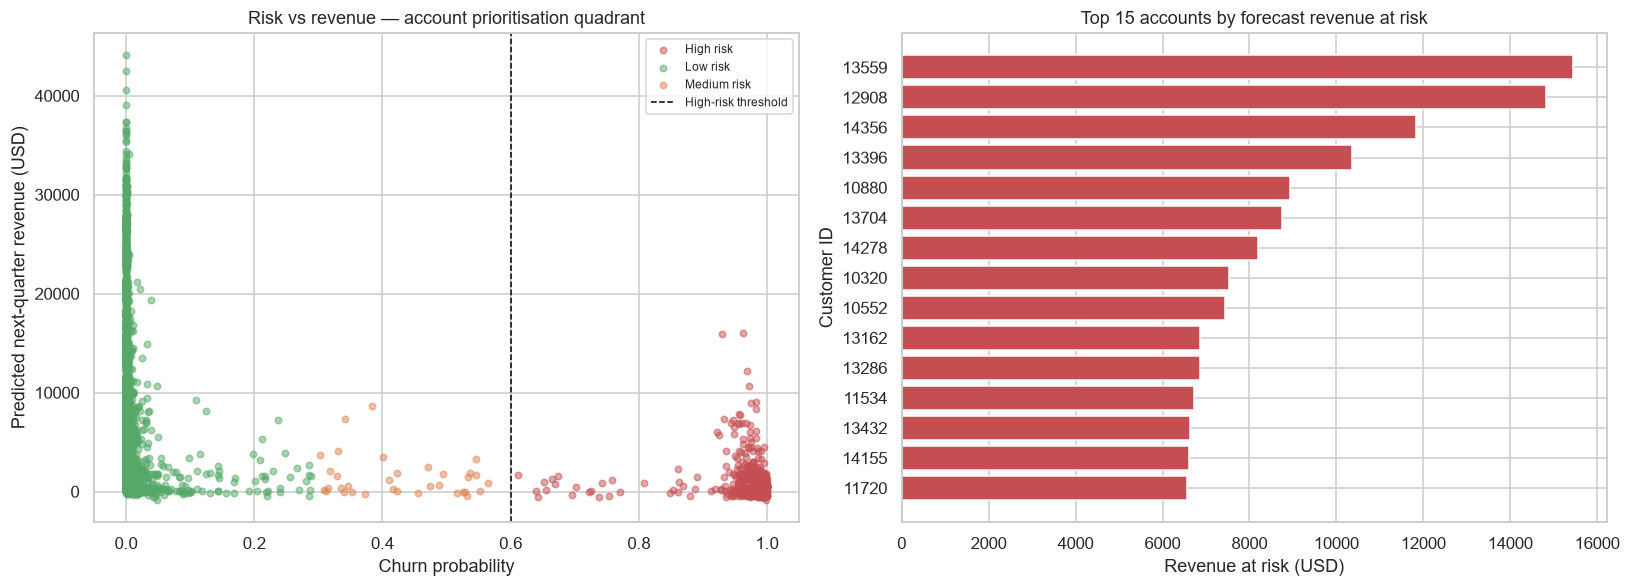

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

risk_colors = {"Low": "#55A868", "Medium": "#DD8452", "High": "#C44E52"}
for level, group in fusion.groupby("risk_level"):
    axes[0].scatter(group["churn_probability"],
                    group["predicted_next_quarter_revenue_usd"],
                    alpha=0.5, s=18, label=f"{level} risk",
                    color=risk_colors.get(level, "grey"))
axes[0].axvline(0.6, color="black", linestyle="--", linewidth=1,
                label="High-risk threshold")
axes[0].set_xlabel("Churn probability")
axes[0].set_ylabel("Predicted next-quarter revenue (USD)")
axes[0].set_title("Risk vs revenue — account prioritisation quadrant")
axes[0].legend(fontsize=8)

top_accounts = fusion.nlargest(15, "revenue_at_risk_usd")
axes[1].barh(top_accounts["Customer_ID"].astype(str),
             top_accounts["revenue_at_risk_usd"], color="#C44E52")
axes[1].set_xlabel("Revenue at risk (USD)")
axes[1].set_ylabel("Customer ID")
axes[1].set_title("Top 15 accounts by forecast revenue at risk")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Summary

| Model | Task | Headline metric |
| --- | --- | --- |
| XGBoost classifier | Churn prediction | ROC-AUC 0.9023, F1 0.6020 |
| GradientBoosting regressor | Next-quarter revenue | R² 0.9674, RMSE $1,363 |
| KMeans (k=2, PCA) | Behavioural segmentation | Silhouette 0.376 |

The fused intelligence layer converts these into per-account risk, revenue and
priority scores, which `llm_insights.py` narrates into executive briefings
(`reports/executive_insights.md`).

**Known limitations**

1. **Residual leakage risk.** The four clearest temporal artefacts are withheld
   (section 3.3), but other aggregates such as `txn_total_revenue_usd` and
   `Lifetime_Revenue_USD` also scale with how long an account survived. A
   production rebuild should compute every feature from a fixed observation
   window closing before the prediction date.
2. **Recall ceiling.** 52.2% of churners caught at 71.1% precision, using the
   default 0.5 threshold. No threshold tuning was performed; the right operating
   point depends on outreach cost versus the value of a saved account.
3. The `Cluster_Label_*` dummies shipped with the source data are withheld from
   both supervised models — they are a pre-baked segment tag that encodes churn
   risk directly.
4. Silhouette of 0.376 does not meet the 0.60 target — see section 5.